In [2]:
import pandas as pd
import numpy as np

In [3]:
# '914_seap_pr-resultado-preliminar-prova-objetiva-2025-06-30.xlsx'
# pasta_destino = '../../2025-02-10 SEFAZ-PR/'
# arquivo_excel = '914_seap_pr-resultado-preliminar-prova-objetiva-2025-06-30.xlsx'

configuracao = {
    'pr_obj_pre':{
        'nome_colunas':['inscricao','nome','nascimento','por', 'rlm', 'ap', 'ad', 'da', 'dce','dc', 'lt', 'dt', 'efp', 'cga', 'pad','obj','situacao'],
        'converte':['por', 'rlm', 'ap', 'ad', 'da', 'dce','dc', 'lt', 'dt', 'efp', 'cga', 'pad','obj'],
        'pasta_destino':'../../2025-02-10 SEFAZ-PR/',
        'arquivo_excel':'914_seap_pr-resultado-preliminar-prova-objetiva-2025-06-30.xlsx',
        'arquivo_saida':'sefaz-pr_obj-preliminar.xlsx',
    },
    'pr_obj_def':{
        'nome_colunas':['inscricao','nome','nascimento','por', 'rlm', 'ap', 'ad', 'da', 'dce','dc', 'lt', 'dt', 'efp', 'cga', 'pad','obj','situacao'],
        'converte':['por', 'rlm', 'ap', 'ad', 'da', 'dce','dc', 'lt', 'dt', 'efp', 'cga', 'pad','obj'],
        'pasta_destino':'../../2025-02-10 SEFAZ-PR/',
        'arquivo_excel':'914-seap-pr-resultado-definitivo-prova-objetiva.xlsx',
        'arquivo_saida':'sefaz-pr_obj-definitivo.xlsx',
    },
    'pr_disc_def':{
        'nome_colunas':['inscricao','nome','cont','port','disc','situacao'],
        'converte':['cont','port','disc'],
        'pasta_destino':'../../2025-02-10 SEFAZ-PR/',
        'arquivo_excel':'914-seap-pr-resultado-preliminar-prova-discursiva.xlsx',
        'arquivo_saida':'sefaz-pr_disc-preliminar.xlsx',
    },
    'pi_obj_pre':{
        'nome_colunas':['numero','nome','pontos','class',],
        'converte':['pontos','class',],
        'pasta_destino':'../../2025-03-22 SEFAZ-PI/',
        'arquivo_excel':'edital_divulgacao_do_resultado_preliminar_da_prova_objetiva.xlsx',
        'arquivo_saida':'sefaz-pi_obj-preliminar.xlsx',
    }
}

dict_arquivo = configuracao['pi_obj_pre']

# Carregar todas as abas como dicionário de DataFrames
abas = pd.read_excel(dict_arquivo['pasta_destino'] + dict_arquivo['arquivo_excel'], sheet_name=None, dtype=str, header=None)

In [4]:
df_concatenar = []

# Agora você pode acessar cada aba pelo nome
for nome_aba, df in abas.items():
    # print(f"Aba: {nome_aba}")
    # print(df.head())  # Exibe as primeiras linhas de cada aba
    if df.shape[1] > 2:
        # print(df.shape)
        df_concatenar.append(df)

In [5]:
df_concat = pd.concat(df_concatenar)

In [6]:
df_concat.columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype='int64')

In [7]:
df_concat.columns = dict_arquivo['nome_colunas']
df_filtrado = df_concat[df_concat.iloc[:,0] != 'Inscrição']
df_filtrado = df_filtrado[~df_filtrado.iloc[:,0].isna()]

for coluna in dict_arquivo['converte']:
    df_filtrado[coluna] = df_filtrado[coluna].astype('float')

df_filtrado

ValueError: Length mismatch: Expected axis has 11 elements, new values have 4 elements

In [124]:
df_filtrado.to_excel(dict_arquivo['pasta_destino'] + dict_arquivo['arquivo_saida'], index=False)

# Junta Objetiva e discursiva

In [1]:
# configuracao = {
#     'pr_obj_pre':{
#         'nome_colunas':['inscricao','nome','nascimento','por', 'rlm', 'ap', 'ad', 'da', 'dce','dc', 'lt', 'dt', 'efp', 'cga', 'pad','obj','situacao'],
#         'converte':['por', 'rlm', 'ap', 'ad', 'da', 'dce','dc', 'lt', 'dt', 'efp', 'cga', 'pad','obj'],
#         'pasta_destino':'../../2025-02-10 SEFAZ-PR/',
#         'arquivo_excel':'914_seap_pr-resultado-preliminar-prova-objetiva-2025-06-30.xlsx',
#         'arquivo_saida':'sefaz-pr_obj-preliminar.xlsx',
#     },
#     'pr_obj_def':{
#         'nome_colunas':['inscricao','nome','nascimento','por', 'rlm', 'ap', 'ad', 'da', 'dce','dc', 'lt', 'dt', 'efp', 'cga', 'pad','obj','situacao'],
#         'converte':['por', 'rlm', 'ap', 'ad', 'da', 'dce','dc', 'lt', 'dt', 'efp', 'cga', 'pad','obj'],
#         'pasta_destino':'../../2025-02-10 SEFAZ-PR/',
#         'arquivo_excel':'914-seap-pr-resultado-definitivo-prova-objetiva.xlsx',
#         'arquivo_saida':'sefaz-pr_obj-definitivo.xlsx',
#     },
#     'pr_obj_def':{

df_obj = pd.read_excel(configuracao['pr_obj_def']['pasta_destino'] + configuracao['pr_obj_def']['arquivo_saida'])
df_disc = pd.read_excel(configuracao['pr_obj_def']['pasta_destino'] + configuracao['pr_disc_def']['arquivo_saida'])

NameError: name 'pd' is not defined

In [129]:
df_disc

,inscricao,nome,cont,port,disc,situacao
0,914012870,Abel Da Silva Chaves,4.5,8.0,12.5,Aprovado
1,914000401,Abelardo José Varêda Lapenda Filho,4.0,7.8,11.8,Aprovado
2,914000874,Adalberto Gregório Back,6.5,7.8,14.3,Aprovado
3,914000134,Adari Rogério De Almeida,5.0,8.0,13.0,Aprovado
4,914022524,Adelmo Irineu Severino,4.0,7.5,11.5,Aprovado
...,...,...,...,...,...,...
1520,914005649,Yrlane Santos Araújo,6.0,7.8,13.8,Aprovado
1521,914001097,Yuri Barbosa Lemos,4.0,7.8,11.8,Aprovado
1522,914000485,Yuri Fernando Barbosa Torres,4.0,7.9,11.9,Aprovado
1523,914019295,Yuri Rosendo De Miranda Silva,5.0,7.9,12.9,Aprovado


In [155]:
df_geral = df_obj.merge(df_disc,on='inscricao',suffixes=['_obj','_disc'],how='outer')
df_geral['total'] = df_geral['disc'].fillna(12.18) + df_geral['obj']
df_geral = df_geral.sort_values(by='total',ascending=False).reset_index(drop=True)
df_geral

,inscricao,nome_obj,nascimento,por,rlm,ap,ad,da,dce,dc,...,cga,pad,obj,situacao_obj,nome_disc,cont,port,disc,situacao_disc,total
0,914002077,Gabriel Melo Nunes,1996-11-15 00:00:00,8,8,6,9,7,6,7,...,19.2,19.2,122.4,Aprovado,Gabriel Melo Nunes,6.0,7.8,13.8,Aprovado,136.20
1,914000597,Gabriel Tostes Bianco,1989-11-09 00:00:00,9,10,6,8,6,6,7,...,21.6,16.8,121.2,Aprovado,Gabriel Tostes Bianco,7.0,8.0,15.0,Aprovado,136.20
2,914003874,Gabriel Mendonça Santana,1997-07-01 00:00:00,8,9,5,9,6,7,6,...,21.6,19.2,122.8,Aprovado,Gabriel Mendonça Santana,5.0,8.0,13.0,Aprovado,135.80
3,914010495,Rafael Della Giustina Basilone Leite,1999-11-17 00:00:00,7,10,6,10,6,8,5,...,20.4,16.8,119.8,Aprovado,Rafael Della Giustina Basilone Leite,7.0,7.8,14.8,Aprovado,134.60
4,914017617,Alexandre Cunningham Gmyterco,1993-10-30 00:00:00,8,5,5,9,7,7,6,...,24.0,20.4,122.0,Aprovado,Alexandre Cunningham Gmyterco,4.5,8.0,12.5,Aprovado,134.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2354,914019519,Kelvin Alexander Bernz,1989-10-30 00:00:00,4,2,4,4,5,4,4,...,9.6,14.4,73.6,Aprovado,Kelvin Alexander Bernz,2.5,7.8,10.3,Aprovado,83.90
2355,914000206,Rafael Veloso Moroz,1987-02-05 00:00:00,5,3,5,5,2,3,3,...,8.4,13.2,73.6,Aprovado,Rafael Veloso Moroz,2.5,7.5,10.0,Aprovado,83.60
2356,914023917,Alan Guimarães Da Silva,1998-10-23 00:00:00,8,5,5,5,3,3,1,...,9.6,10.8,71.4,Aprovado,NaN,NaN,NaN,NaN,NaN,83.58
2357,914009943,Anderson Akio Gohara,1991-03-15 00:00:00,9,9,4,9,4,3,2,...,6.0,18.0,73.4,Aprovado,Anderson Akio Gohara,2.5,7.5,10.0,Aprovado,83.40


In [156]:
df_obj[df_obj['nome'].str.contains('Carlos Vinicius')]

,inscricao,nome,nascimento,por,rlm,ap,ad,da,dce,dc,lt,dt,efp,cga,pad,obj,situacao
782,914004603,Carlos Vinicius De Freitas Silva,1985-10-16 00:00:00,7,9,5,8,2,5,2,8.4,6.0,8,19.2,19.2,98.8,Aprovado


In [159]:
df_geral[df_geral['nome_obj'].str.contains('Carlos Vinicius')]

,inscricao,nome_obj,nascimento,por,rlm,ap,ad,da,dce,dc,...,cga,pad,obj,situacao_obj,nome_disc,cont,port,disc,situacao_disc,total
781,914004603,Carlos Vinicius De Freitas Silva,1985-10-16 00:00:00,7,9,5,8,2,5,2,...,19.2,19.2,98.8,Aprovado,NaN,NaN,NaN,NaN,NaN,110.98


In [161]:
df_geral[df_geral['total'] < 110.78 - 12.18 + 8.1]

,inscricao,nome_obj,nascimento,por,rlm,ap,ad,da,dce,dc,...,cga,pad,obj,situacao_obj,nome_disc,cont,port,disc,situacao_disc,total
1124,914025136,Francisco Rogeano Sousa Beserra,1986-07-06 00:00:00,8,8,5,7,4,4,3,...,13.2,13.2,93.8,Aprovado,Francisco Rogeano Sousa Beserra,5.0,7.8,12.8,Aprovado,106.60
1125,914008986,Luan Da Silva De Souza,1991-05-06 00:00:00,9,7,6,7,5,4,3,...,13.2,14.4,95.6,Aprovado PcD Negro,Luan Da Silva De Souza,3.0,8.0,11.0,Aprovado PcD Negro,106.60
1126,914000134,Adari Rogério De Almeida,1984-05-29 00:00:00,9,8,4,8,5,7,2,...,13.2,14.4,93.6,Aprovado,Adari Rogério De Almeida,5.0,8.0,13.0,Aprovado,106.60
1127,914015934,Jefferson Emanoel Soares Gama,1991-05-13 00:00:00,8,7,6,7,7,4,4,...,15.6,12.0,93.6,Aprovado Negro,Jefferson Emanoel Soares Gama,5.0,8.0,13.0,Aprovado Negro,106.60
1128,914006017,Tatiane Marlei Defrein Rieger,1981-10-19 00:00:00,6,5,5,6,7,4,2,...,22.8,8.4,95.6,Aprovado,Tatiane Marlei Defrein Rieger,3.0,8.0,11.0,Aprovado,106.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2354,914019519,Kelvin Alexander Bernz,1989-10-30 00:00:00,4,2,4,4,5,4,4,...,9.6,14.4,73.6,Aprovado,Kelvin Alexander Bernz,2.5,7.8,10.3,Aprovado,83.90
2355,914000206,Rafael Veloso Moroz,1987-02-05 00:00:00,5,3,5,5,2,3,3,...,8.4,13.2,73.6,Aprovado,Rafael Veloso Moroz,2.5,7.5,10.0,Aprovado,83.60
2356,914023917,Alan Guimarães Da Silva,1998-10-23 00:00:00,8,5,5,5,3,3,1,...,9.6,10.8,71.4,Aprovado,NaN,NaN,NaN,NaN,NaN,83.58
2357,914009943,Anderson Akio Gohara,1991-03-15 00:00:00,9,9,4,9,4,3,2,...,6.0,18.0,73.4,Aprovado,Anderson Akio Gohara,2.5,7.5,10.0,Aprovado,83.40


In [153]:
df_disc.describe()

,inscricao,cont,port,disc
count,1.525000e+03,1525.000000,1525.000000,1525.000000
mean,9.140096e+08,4.342623,7.843475,12.186098
std,7.412323e+03,1.271980,0.190743,1.296129
min,9.140000e+08,2.500000,6.500000,9.200000
25%,9.140024e+08,3.500000,7.700000,11.200000
50%,9.140087e+08,4.000000,7.900000,12.000000
75%,9.140157e+08,5.000000,8.000000,13.000000
max,9.140271e+08,7.000000,8.000000,15.000000


# SEFAZ PI
### Tratamento

In [8]:
df_tratamento = df_concat.copy().reset_index(names="index_antigo")
# 63 acima de 8
df_longo = df_tratamento[df_tratamento[0].str.len() > 8]

In [9]:
df_longo[df_longo[0].str.contains('CARGO/ÁREA DE CONHECIMENTO')]

,index_antigo,0,1,2,3,4,5,6,7,8,9,10
15,15,CARGO/ÁREA DE CONHECIMENTO: A01 - AG DE TRIB D...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
455,6,CARGO/ÁREA DE CONHECIMENTO: B02 - AG DE TRIB D...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
489,40,CARGO/ÁREA DE CONHECIMENTO: C03 - AN DO TESOUR...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
628,58,CARGO/ÁREA DE CONHECIMENTO: D04 - AN DO TESOUR...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
644,1,CARGO/ÁREA DE CONHECIMENTO: E05 - AUD FISC DA ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1314,56,CARGO/ÁREA DE CONHECIMENTO: F06 - AUD FISC DA ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1358,1,CARGO/ÁREA DE CONHECIMENTO: G07 - AUD GOVERNAM...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1415,1,CARGO/ÁREA DE CONHECIMENTO: H08 - AUD GOVERNAM...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1430,16,CARGO/ÁREA DE CONHECIMENTO: I09 - AUD GOVERNAM...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1472,2,CARGO/ÁREA DE CONHECIMENTO: A01 - AG DE TRIB D...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
def get_trata_pi(df):
    df[['pontos','class']] = df.apply(lambda x: [v for k,v in x.items() if isinstance(v, str)][-2:],axis=1).apply(pd.Series)
    df.rename(columns={0:'inscricao',1:'nome'},inplace=True)
    df = df[~df['pontos'].str.contains('PONTOS')][['inscricao','nome','pontos','class']]
    df['pontos'] = df['pontos'].astype(float)
    df['class'] = df['class'].astype(int)

    return df.reset_index(drop=True)

In [11]:
df_ampla = get_trata_pi(df_tratamento.loc[644+1:1314-2].copy())
df_pcd = get_trata_pi(df_tratamento.loc[1504+1:1542-2].copy())
df_negros = get_trata_pi(df_tratamento.loc[1727+1:1893-2].copy())

In [ ]:
corte_pi_100_ajustado  = sefazpi[sefazpi['aprovado']].sort_values(by='obj_prc',ascending=False).iloc[75]['obj_prc']
sefazpi_100_ajustado = sefazpi[(sefazpi['aprovado']) & (sefazpi['obj_prc'] >= corte_pi_100_ajustado)]

In [24]:
df_ampla_top100 = df_ampla[df_ampla['class'] <= 100].copy()
df_ampla_top100_stat = df_ampla_top100.describe()
df_ampla_top100_stat

,pontos,class
count,100.0000,100.000000
mean,215.2978,49.960000
std,4.7928,28.667343
min,209.3400,1.000000
25%,211.2450,24.000000
50%,213.9400,50.000000
75%,218.7800,74.500000
max,232.0600,99.000000


In [12]:
df_ampla[df_ampla['nome'].str.contains('CARLOS VINICIUS DE FREITAS SILVA')]

,inscricao,nome,pontos,class
511,0012484j,CARLOS VINICIUS DE FREITAS SILVA,186.17,510


In [25]:
(186.17-215.2978)/4.7928

-6.07740777833417

In [188]:
df_ampla['pcd'] = df_ampla['inscricao'].isin(df_pcd['inscricao']).astype(int)
df_ampla['negros'] = df_ampla['inscricao'].isin(df_negros['inscricao']).astype(int)
df_ampla['pcd_acum'] = df_ampla['pcd'].cumsum()
df_ampla['negros_acum'] = df_ampla['negros'].cumsum()
df_ampla['pcd_pct'] = df_ampla['pcd_acum']/df_ampla['class']
df_ampla['negros_pct'] = df_ampla['negros_acum']/df_ampla['class']

<Axes: >

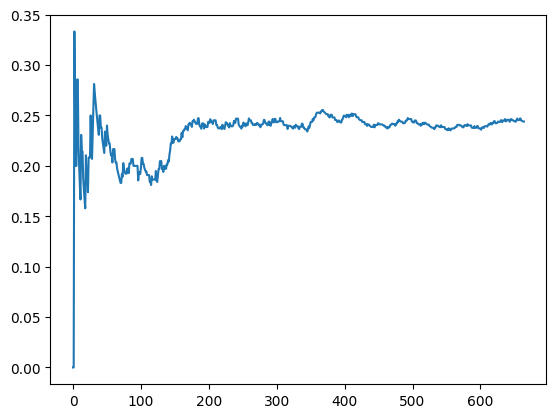

In [191]:
df_ampla['negros_pct'].plot()

In [97]:
df = df_ampla
x = df.iloc[5]

# df[['pontos','class']] = [1,2]
df[["b", "c"]] = df.apply(lambda x: [v for k,v in x.items() if isinstance(v, str)][-2:],axis=1)

ValueError: Columns must be same length as key